# Flat Price Prediction : Linear Regression

Predict `Price_Lakh` from `Area_Sqft`, `Facing`, `Floor`, `Car_Parking_Sqft`, `Bedrooms` using Linear Regression.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import joblib

sns.set_style("whitegrid")
RANDOM_STATE = 42

## 2. Load the data

In [2]:
df = pd.read_excel("Flat_Price_Multiple_Linear_Regression_100.xlsx")
print(df.shape)
df.head()

(100, 7)


,Flat_ID,Area_Sqft,Facing,Floor,Car_Parking_Sqft,Bedrooms,Price_Lakh
0,1,850,North,1,100,2,43
1,2,920,South,2,110,2,50
2,3,1050,East,3,120,2,57
3,4,1150,West,4,130,3,63
4,5,1250,North,5,140,3,70


## 3. EDA

In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Flat_ID           100 non-null    int64 
 1   Area_Sqft         100 non-null    int64 
 2   Facing            100 non-null    object
 3   Floor             100 non-null    int64 
 4   Car_Parking_Sqft  100 non-null    int64 
 5   Bedrooms          100 non-null    int64 
 6   Price_Lakh        100 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 5.6+ KB


Flat_ID             0
Area_Sqft           0
Facing              0
Floor               0
Car_Parking_Sqft    0
Bedrooms            0
Price_Lakh          0
dtype: int64

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Flat_ID,100.0,NaN,NaN,NaN,50.5,29.011492,1.0,25.75,50.5,75.25,100.0
Area_Sqft,100.0,NaN,NaN,NaN,1309.4,283.986129,850.0,1057.5,1290.0,1552.5,1850.0
Facing,100,4,North,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,100.0,NaN,NaN,NaN,5.9,2.928439,1.0,3.0,6.0,8.0,11.0
Car_Parking_Sqft,100.0,NaN,NaN,NaN,145.0,29.050635,100.0,120.0,145.0,170.0,200.0
Bedrooms,100.0,NaN,NaN,NaN,2.95,0.641573,2.0,3.0,3.0,3.0,4.0
Price_Lakh,100.0,NaN,NaN,NaN,75.38,19.963998,43.0,58.5,74.5,91.25,119.0


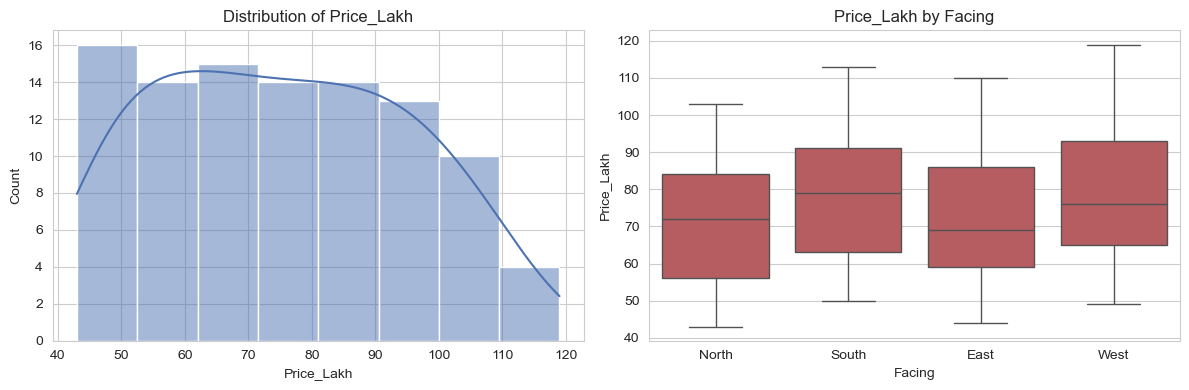

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Price_Lakh"], kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Price_Lakh")
sns.boxplot(x="Facing", y="Price_Lakh", data=df, order=["North", "South", "East", "West"], ax=axes[1], color="#C44E52")
axes[1].set_title("Price_Lakh by Facing")
plt.tight_layout()
plt.show()

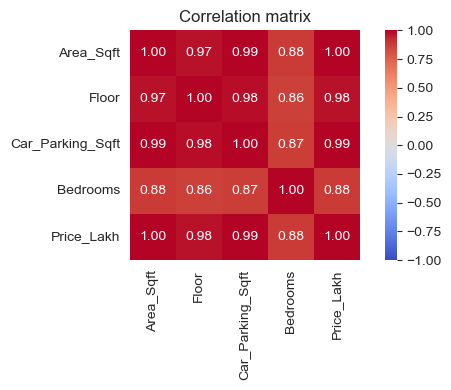

In [6]:
corr_cols = ["Area_Sqft", "Floor", "Car_Parking_Sqft", "Bedrooms", "Price_Lakh"]
plt.figure(figsize=(6, 4))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

## 4. Feature engineering

In [7]:
X = df.drop(columns=["Flat_ID", "Price_Lakh"])
y = df["Price_Lakh"]
X.head()

,Area_Sqft,Facing,Floor,Car_Parking_Sqft,Bedrooms
0,850,North,1,100,2
1,920,South,2,110,2
2,1050,East,3,120,2
3,1150,West,4,130,3
4,1250,North,5,140,3


## 5. Train/test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (80, 5)  Test: (20, 5)


## 6. Train the Linear Regression model

Preprocessing (`OneHotEncoder` on `Facing`) and the model are combined into a single `Pipeline`.

In [9]:
preprocessor = ColumnTransformer(
    transformers=[("facing_ohe", OneHotEncoder(drop="first", handle_unknown="ignore"), ["Facing"])],
    remainder="passthrough"
)

model = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('facing_ohe', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 7. Evaluation

In [10]:
# Test-set predictions
y_pred = model.predict(X_test)

# 1. Test-set evaluation
test_r2 = r2_score(y_test, y_pred)
test_rmse = mean_squared_error(y_test, y_pred) ** 0.5
test_mae = mean_absolute_error(y_test, y_pred)

# 2. Train-set evaluation
y_train_pred = model.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = mean_squared_error(y_train, y_train_pred) ** 0.5
train_mae = mean_absolute_error(y_train, y_train_pred)

# 3. Display Train vs Test
print("TRAIN PERFORMANCE")
print(f"R2   : {train_r2:.4f}")
print(f"RMSE : {train_rmse:.3f} Lakh")
print(f"MAE  : {train_mae:.3f} Lakh")
print("\nTEST PERFORMANCE")
print(f"R2   : {test_r2:.4f}")
print(f"RMSE : {test_rmse:.3f} Lakh")
print(f"MAE  : {test_mae:.3f} Lakh")

TRAIN PERFORMANCE
R2   : 0.9947
RMSE : 1.412 Lakh
MAE  : 1.027 Lakh

TEST PERFORMANCE
R2   : 0.9979
RMSE : 0.803 Lakh
MAE  : 0.631 Lakh


In [11]:
# 5-Fold Cross-Validation
kf = KFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
cv_results = cross_validate(
    model,
    X,
    y,
    cv=kf,
    scoring={
        "R2": "r2",
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error"
    },
    return_train_score=False
)
cv_r2 = cv_results["test_R2"]

# sklearn returns MAE/RMSE as negative values
cv_mae = -cv_results["test_MAE"]
cv_rmse = -cv_results["test_RMSE"]
print("5-FOLD CROSS-VALIDATION")
print(f"R2   : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"MAE  : {cv_mae.mean():.3f} ± {cv_mae.std():.3f} Lakh")
print(f"RMSE : {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f} Lakh")

5-FOLD CROSS-VALIDATION
R2   : 0.9939 ± 0.0035
MAE  : 1.009 ± 0.303 Lakh
RMSE : 1.344 ± 0.485 Lakh


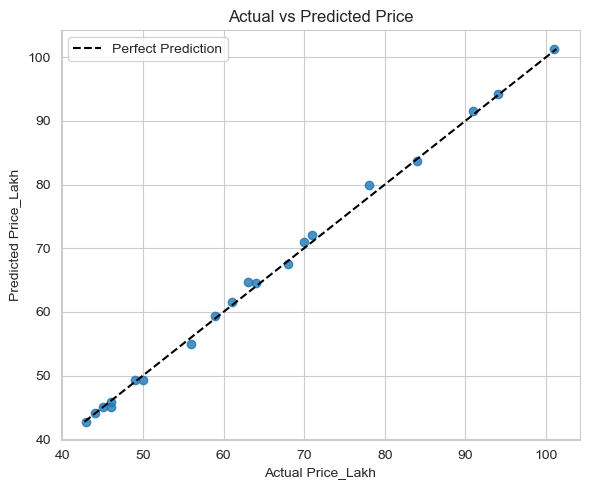

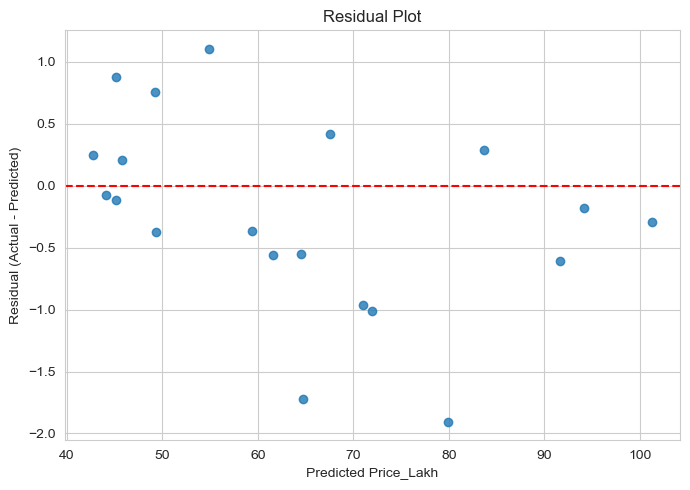

In [12]:
# Actual vs Predicted
plt.figure(figsize=(6, 5))
plt.scatter(y_test,y_pred,alpha=0.8)
lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]
plt.plot(lims,lims,"k--",label="Perfect Prediction")
plt.xlabel("Actual Price_Lakh")
plt.ylabel("Predicted Price_Lakh")
plt.title("Actual vs Predicted Price")
plt.legend()
plt.tight_layout()
plt.show()

# Residual Analysis
residuals = y_test - y_pred
plt.figure(figsize=(7, 5))
plt.scatter(y_pred,residuals,alpha=0.8)
plt.axhline(y=0,linestyle="--",color="red",label="Zero Error Line")
plt.xlabel("Predicted Price_Lakh")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

## 8. Coefficients

In [13]:
feature_names = model.named_steps["preprocess"].get_feature_names_out()
coefs = model.named_steps["regressor"].coef_

pd.DataFrame({"feature": feature_names, "coefficient": coefs})

,feature,coefficient
0,facing_ohe__Facing_North,-0.101208
1,facing_ohe__Facing_South,1.028478
2,facing_ohe__Facing_West,0.234248
3,remainder__Area_Sqft,0.060813
4,remainder__Floor,0.437499
5,remainder__Car_Parking_Sqft,0.024505
6,remainder__Bedrooms,1.156441


## 9. Save the pipeline

Refitting on the full dataset (all 100 rows) for the deployed model, then saving preprocessing + model together as one file - this is what the backend API will load.

In [14]:
model.fit(X, y)
joblib.dump(model, "flat_price_pipeline.joblib")
print("Saved: flat_price_pipeline.joblib")

Saved: flat_price_pipeline.joblib


## 10. Sanity check - reload and predict

In [15]:
loaded_model = joblib.load("flat_price_pipeline.joblib")

sample = pd.DataFrame([{
    "Area_Sqft": 1000,
    "Facing": "East",
    "Floor": 5,
    "Car_Parking_Sqft": 140,
    "Bedrooms": 4
}])

print("Predicted Price_Lakh:", round(loaded_model.predict(sample)[0], 2))

Predicted Price_Lakh: 56.65
